# IPL - 2022 Capstone Project

In [1]:
import cufflinks as cf
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.offline import iplot
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [2]:
df = pd.read_csv('./IPL.csv')
df

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


In [3]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


In [3]:
print(f"Number of rows: {df.shape[0]}\nNumber of columns: {df.shape[1]}")

Number of rows: 74
Number of columns: 20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [6]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [7]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,133,3,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17


In [8]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

In [4]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

#### Which team won the most matches?

In [10]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

In [8]:
most_match_winner = df['match_winner'].value_counts().sort_values(ascending=False).head(5)
most_match_winner

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Name: count, dtype: int64

In [9]:
df[df['match_winner'] == most_match_winner.idxmax()]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
9,10,"April 2,2022","Maharashtra Cricket Association Stadium,Pune",Delhi,Gujarat,Group,Delhi,Field,171,6,157,9,Gujarat,Runs,14,Lockie Ferguson,Shubman Gill,84,Lockie Ferguson,4--28
15,16,"April 8,2022","Brabourne Stadium, Mumbai",Gujarat,Punjab,Group,Gujarat,Field,189,9,190,4,Gujarat,Wickets,6,Shubman Gill,Shubman Gill,96,Rashid Khan,3--22
23,24,"April 14,2022","Dr DY Patil Sports Academy, Mumbai",Gujarat,Rajasthan,Group,Rajasthan,Field,192,4,155,9,Gujarat,Runs,37,Hardik Pandya,Hardik Pandya,87,Lockie Ferguson,3--23
28,29,"April 17,2022","Maharashtra Cricket Association Stadium,Pune",Chennai,Gujarat,Group,Gujarat,Field,169,5,170,7,Gujarat,Wickets,3,David Miller,David Miller,94,Dwayne Bravo,3--23
34,35,"April 23,2022","Dr DY Patil Sports Academy, Mumbai",Gujarat,Kolkata,Group,Gujarat,Bat,156,9,148,8,Gujarat,Runs,8,Rashid Khan,Hardik Pandya,67,Andre Russell,4--5
39,40,"April 27,2022","Wankhede Stadium, Mumbai",Gujarat,Hyderabad,Group,Gujarat,Field,195,6,199,5,Gujarat,Wickets,5,Umran Malik,W. Saha,68,Umran Malik,5--25
42,43,"April 30,2022","Brabourne Stadium, Mumbai",Banglore,Gujarat,Group,Banglore,Bat,170,6,174,4,Gujarat,Wickets,6,Rahul Tewatia,Virat Kohli,58,Pradeep Sangwan,2--19
56,57,"May 10,2022","Maharashtra Cricket Association Stadium,Pune",Lucknow,Gujarat,Group,Gujarat,Bat,144,4,82,10,Gujarat,Runs,62,Shubman Gill,Shubman Gill,63,Rashid Khan,4--24
61,62,"May 15,2022","Wankhede Stadium, Mumbai",Chennai,Gujarat,Group,Chennai,Bat,133,5,137,3,Gujarat,Wickets,7,W. Saha,W. Saha,67,Mohammed Shami,2--19


Text(0.5, 1.0, 'Most match wins by team')

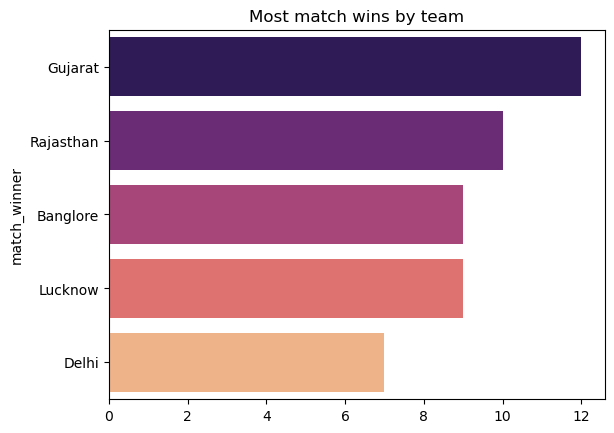

In [10]:
sns.barplot(y=most_match_winner.index, x=most_match_winner.values, palette='magma')
plt.title('Most match wins by team')

### Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

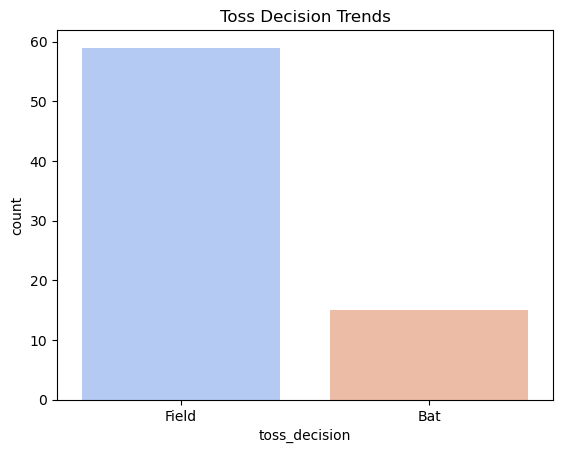

In [11]:
sns.countplot(x=df['toss_decision'], palette='coolwarm')
plt.title('Toss Decision Trends')

### Toss Winner VS Match Winner

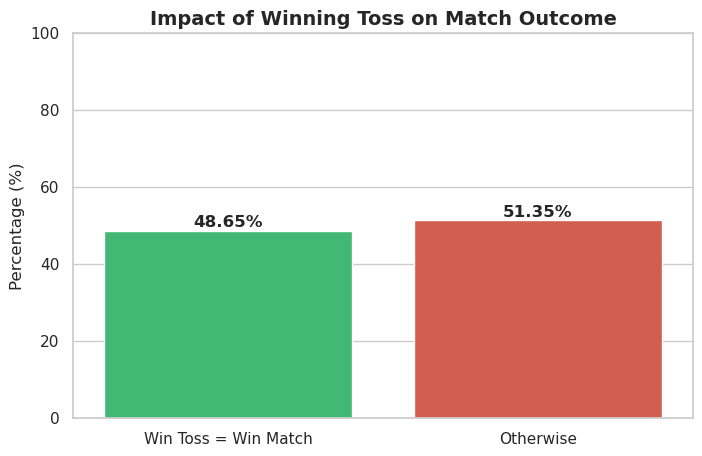

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Theme (makes everything look cleaner)
sns.set_theme(style="whitegrid")

labels = ['Win Toss = Win Match', 'Otherwise']
values = [
    (df['toss_winner'] == df['match_winner']).mean() * 100,
    100 - (df['toss_winner'] == df['match_winner']).mean() * 100
]

# Palette (nice contrasting colors)
palette = ['#2ecc71', '#e74c3c']  # green = success, red = failure

plt.figure(figsize=(8, 5))

ax = sns.barplot(x=labels, y=values, palette=palette)

# Add value labels on top of bars
for i, v in enumerate(values):
    ax.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.title("Impact of Winning Toss on Match Outcome", fontsize=14, fontweight='bold')
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.show()

### How do teams win?

Text(0.5, 1.0, 'Won by')

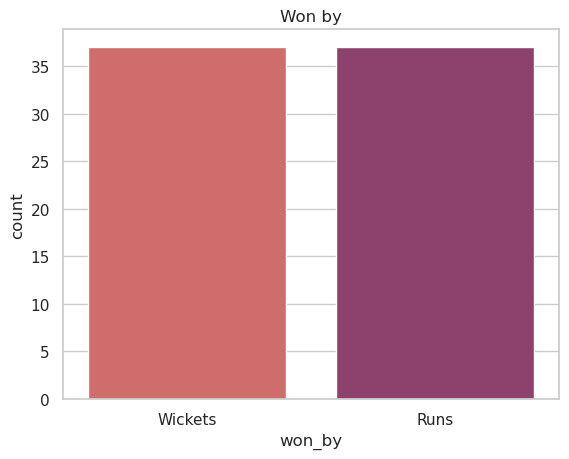

In [13]:
sns.countplot(x=df['won_by'], palette='flare')
plt.title('Won by')

### Most "Player of the Match" awards

In [14]:
count = df['player_of_the_match'].value_counts().nlargest(10)
count

player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

In [18]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

Text(0.5, 1.0, 'Top 10 Players of the Match')

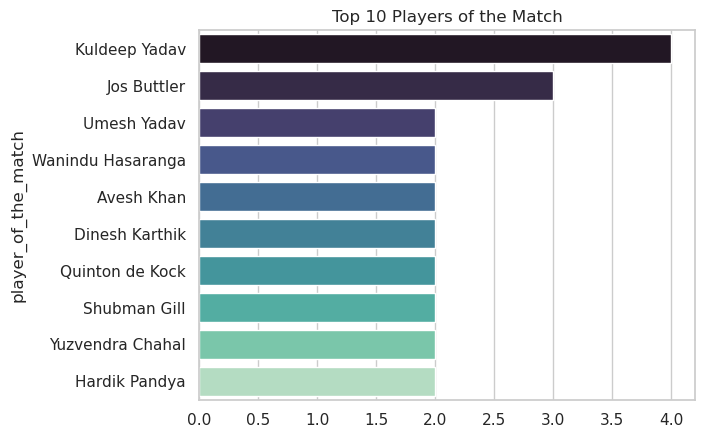

In [15]:
sns.barplot(x=count.values, y=count.index, palette='mako')
plt.title('Top 10 Players of the Match')

In [16]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

Text(0.5, 1.0, 'Top 2 Scorers')

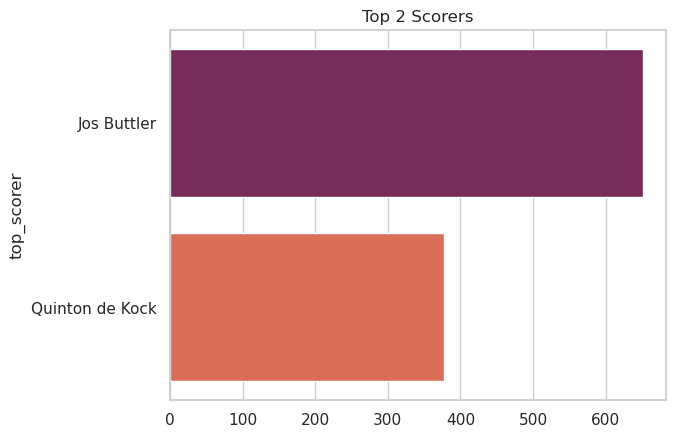

In [17]:
sns.barplot(x=high.values, y=high.index, palette='rocket')
plt.title('Top 2 Scorers')

<Axes: ylabel='top_scorer'>

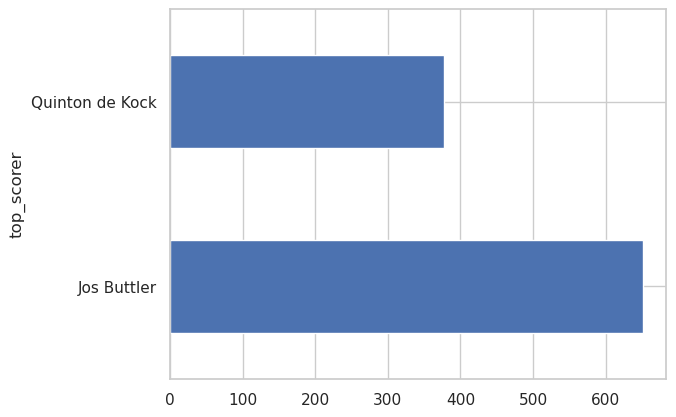

In [18]:
high.plot(kind='barh')

### Most Player of the Match

In [19]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

In [31]:
highest_player_of_the_match_awards = df['player_of_the_match'].value_counts().sort_values(ascending=False).head(5)
highest_player_of_the_match_awards

player_of_the_match
Kuldeep Yadav       4
Jos Buttler         3
Yuzvendra Chahal    2
Jasprit Bumrah      2
David Miller        2
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Player of the Match Awards winner')

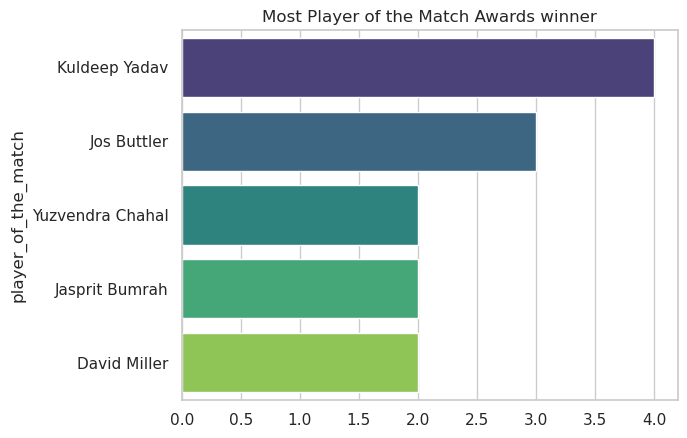

In [32]:
sns.barplot(
    y=highest_player_of_the_match_awards.index,
    x=highest_player_of_the_match_awards.values,
    palette='viridis'
)
plt.title('Most Player of the Match Awards winner')

### 10 Best Bowling Figures

In [33]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')

In [36]:
best_bowling_figure = df['best_bowling_figure']
best_bowling_figure

0     3--20
1     3--18
2     2--59
3     3--25
4     3--22
      ...  
69    3--26
70    1--14
71    3--43
72    3--22
73    3--17
Name: best_bowling_figure, Length: 74, dtype: str

In [37]:
best_bowling = df['best_bowling']
best_bowling

0         Dwayne Bravo
1        Kuldeep Yadav
2       Mohammed Siraj
3       Mohammed Shami
4     Yuzvendra Chahal
            ...       
69       Harpreet Brar
70       Hardik Pandya
71      Josh Hazlewood
72     Prasidh Krishna
73       Hardik Pandya
Name: best_bowling, Length: 74, dtype: str

In [38]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])

In [40]:
df['highest_wickets'] = df['highest_wickets'].astype(int)

In [45]:
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wickets, dtype: int64

In [49]:
import plotly.express as px
import plotly.graph_objects as go

# Color each bar based on wicket count
def get_color(val):
    if val >= 6:
        return '#534AB7'  # purple - elite
    elif val >= 4:
        return '#1D9E75'  # teal - solid
    else:
        return '#888780'  # gray - below average

colors = [get_color(v) for v in top_bowlers.values]

fig = go.Figure(go.Bar(
    x=top_bowlers.values,
    y=top_bowlers.index,
    orientation='h',
    marker=dict(
        color=colors,
        line=dict(width=0),
    ),
    text=top_bowlers.values,
    textposition='outside',
    textfont=dict(size=12, color='#5f5e5a'),
))

fig.update_layout(
    title=dict(
        text='Best Bowling Figures',
        font=dict(size=20, color='#2c2c2a'),
        x=0.02
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        gridcolor='rgba(0,0,0,0.07)',
        gridwidth=1,
        zeroline=False,
        showline=False,
        tickfont=dict(size=12, color='#5f5e5a'),
    ),
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=13, color='#2c2c2a'),
    ),
    margin=dict(l=20, r=60, t=60, b=40),
    height=400,
    bargap=0.35,
)

fig.show()